# BA820 — Milestone 4 (Individual)

Sai Leela Rahul Pujari


Refinement: Therapeutic-Area Outcome Risk Segmentation

Goal for M4: keep the M2 outcome-profile segmentation as the baseline, then strengthen credibility using two refinements:
1) **Cross-method validation via K-Means** (does a different clustering approach recover the same risk tiers?).
2) **PCA for interpretability** (what dimensions separate therapeutic areas?).

Please note that the notebook from M2 is mostly reused until section `5. M2 Dendrogram: Hierarchical clustering (Ward + Euclidean)` with modifications to adjust for clarity and conciseness.

Sections `6. Refinement 1: Cross-Method Validation via K-Means` and `7. Refinement 2: Structural Interpretation via PCA` are the new refinements made for this M4 milestone.

Table of contents:

>[0. Setup](#scrollTo=15fa797e)

>[1. Load data + sanity checks](#scrollTo=3a0f966a)

>[2. Subset + outcome normalization (same as M2)](#scrollTo=066b9a0b)

>[3. Therapeutic area representation (Track A vs Track B)](#scrollTo=9ac08bf9)

>[4. Build outcome profiles per therapeutic area](#scrollTo=7f8e500f)


>[5.M2 Dendrogram: Hierarchical clustering (Ward + Euclidean)](#scrollTo=0257fe7e)

>[6. Refinement 1: Cross-Method Validation via K-Means](#scrollTo=6acc5a68)

>[7. Refinement 2: Structural Interpretation via PCA](#scrollTo=ef013465)

>[Business-Facing Cluster Summary](#scrollTo=65e89380)



## 0. Setup
This notebook follows the same dataset and preprocessing logic used in earlier milestones.


In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "drugs.csv"

FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load data + sanity checks
We keep the same base dataset as M2/M3. The analysis focuses on the regulatory outcome `authorisation_status` and the `therapeutic_area` field.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
display(df.head(3))

Raw shape: (1988, 28)


,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...


## 2. Subset + outcome normalization (same as M2)
We restrict outcomes to: **authorised / withdrawn / refused** and drop missing outcomes.

In [3]:
df_q = df.copy()
df_q = df_q.dropna(subset=["authorisation_status"]).copy()

df_q["authorisation_status"] = df_q["authorisation_status"].astype(str).str.strip().str.lower()
allowed_outcomes = {"authorised", "withdrawn", "refused"}

df_q = df_q[df_q["authorisation_status"].isin(allowed_outcomes)].copy()

print("Filtered shape:", df_q.shape)
display(df_q["authorisation_status"].value_counts())

Filtered shape: (1987, 28)


,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57


## 3. Therapeutic area representation (Track A vs Track B)
M2 found Track B (split + explode) prevents fragmentation from multi-label strings; I stick to track B here

In [4]:
def clean_area_string(s: str) -> str:
    """Normalize therapeutic area label spacing/casing without over-normalizing semantics."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def split_areas(s: str, delimiter=";"):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return []
    s = clean_area_string(s)
    if not s:
        return []
    parts = [p.strip() for p in s.split(delimiter)]
    parts = [p for p in parts if p]
    return parts

# Track A (as-is)
df_A = df_q.copy()
df_A["therapeutic_area_clean"] = df_A["therapeutic_area"].apply(clean_area_string)
df_A = df_A[df_A["therapeutic_area_clean"].notna()].copy()

# Track B (explode multi-labels)
df_B = df_q.copy()
df_B["therapeutic_area_list"] = df_B["therapeutic_area"].apply(split_areas)
df_B = df_B.explode("therapeutic_area_list").rename(columns={"therapeutic_area_list": "therapeutic_area_clean"})
df_B["therapeutic_area_clean"] = df_B["therapeutic_area_clean"].apply(clean_area_string)
df_B = df_B[df_B["therapeutic_area_clean"].notna()].copy()

print("Track A shape:", df_A.shape, "unique areas:", df_A["therapeutic_area_clean"].nunique())
print("Track B shape:", df_B.shape, "unique areas:", df_B["therapeutic_area_clean"].nunique())

Track A shape: (1703, 29) unique areas: 669
Track B shape: (2942, 29) unique areas: 546


## 4. Build outcome profiles per therapeutic area
For each therapeutic area, compute counts and proportions of authorised/withdrawn/refused. We keep a **minimum volume threshold** to reduce noise from very small categories (same motivation as M2).

In [5]:
def build_profiles(df_in: pd.DataFrame, area_col: str, outcome_col: str, min_n: int = 30) -> pd.DataFrame:
    ct = pd.crosstab(df_in[area_col], df_in[outcome_col])
    for oc in ["authorised", "withdrawn", "refused"]:
        if oc not in ct.columns:
            ct[oc] = 0
    ct = ct[["authorised", "withdrawn", "refused"]]
    ct["n_total"] = ct.sum(axis=1)
    ct = ct[ct["n_total"] >= min_n].copy()
    for oc in ["authorised", "withdrawn", "refused"]:
        ct[f"p_{oc}"] = ct[oc] / ct["n_total"]
    ct = ct.sort_values("n_total", ascending=False)
    return ct

MIN_N = 30
profiles_B = build_profiles(df_B, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)
print("High-volume areas (Track B):", profiles_B.shape[0])
display(profiles_B.head(10))

profiles_B.to_csv(os.path.join(OUT_DIR, f"profiles_trackB_min{MIN_N}.csv"))

High-volume areas (Track B): 17


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",61,16,0,77,0.792208,0.207792,0.000000
HIV Infections,62,12,0,74,0.837838,0.162162,0.000000
Breast Neoplasms,51,10,2,63,0.809524,0.158730,0.031746
"Carcinoma, Non-Small-Cell Lung",47,13,1,61,0.770492,0.213115,0.016393
Immunization,25,27,0,52,0.480769,0.519231,0.000000
"Arthritis, Rheumatoid",40,10,1,51,0.784314,0.196078,0.019608
Hypertension,30,17,0,47,0.638298,0.361702,0.000000
Myocardial Infarction,24,18,0,42,0.571429,0.428571,0.000000
Diabetes Mellitus,31,7,1,39,0.794872,0.179487,0.025641


### Quick visualization of outcome profiles (top areas)

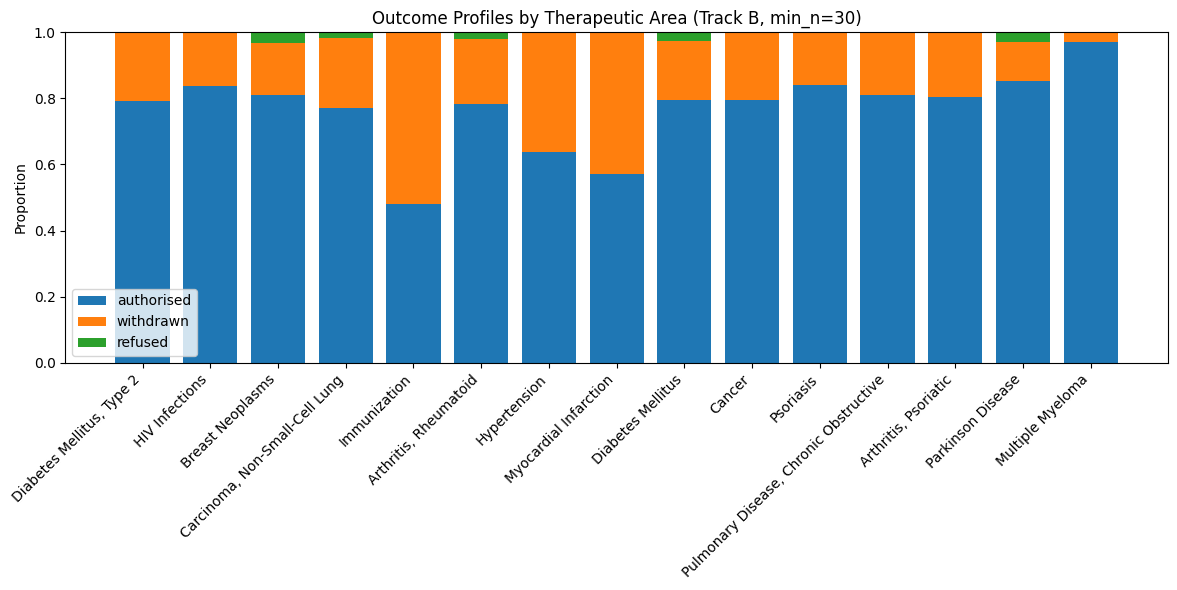

In [6]:
def plot_stacked_profiles(profiles: pd.DataFrame, title: str, top_k: int = 15, save_path: str | None = None):
    sub = profiles.head(top_k).copy()
    areas = sub.index.tolist()
    p_auth = sub["p_authorised"].values
    p_with = sub["p_withdrawn"].values
    p_ref  = sub["p_refused"].values

    x = np.arange(len(areas))
    plt.figure(figsize=(12, 6))
    plt.bar(x, p_auth, label="authorised")
    plt.bar(x, p_with, bottom=p_auth, label="withdrawn")
    plt.bar(x, p_ref, bottom=p_auth + p_with, label="refused")
    plt.xticks(x, areas, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_stacked_profiles(
    profiles_B,
    title=f"Outcome Profiles by Therapeutic Area (Track B, min_n={MIN_N})",
    top_k=15,
    save_path=os.path.join(FIG_DIR, f"stacked_profiles_trackB_min{MIN_N}.png")
)

## 5. M2 Dendrogram: Hierarchical clustering (Ward + Euclidean)
We replicate the M2 dendrogram to establish continuity. Ward focuses on within-cluster variance.

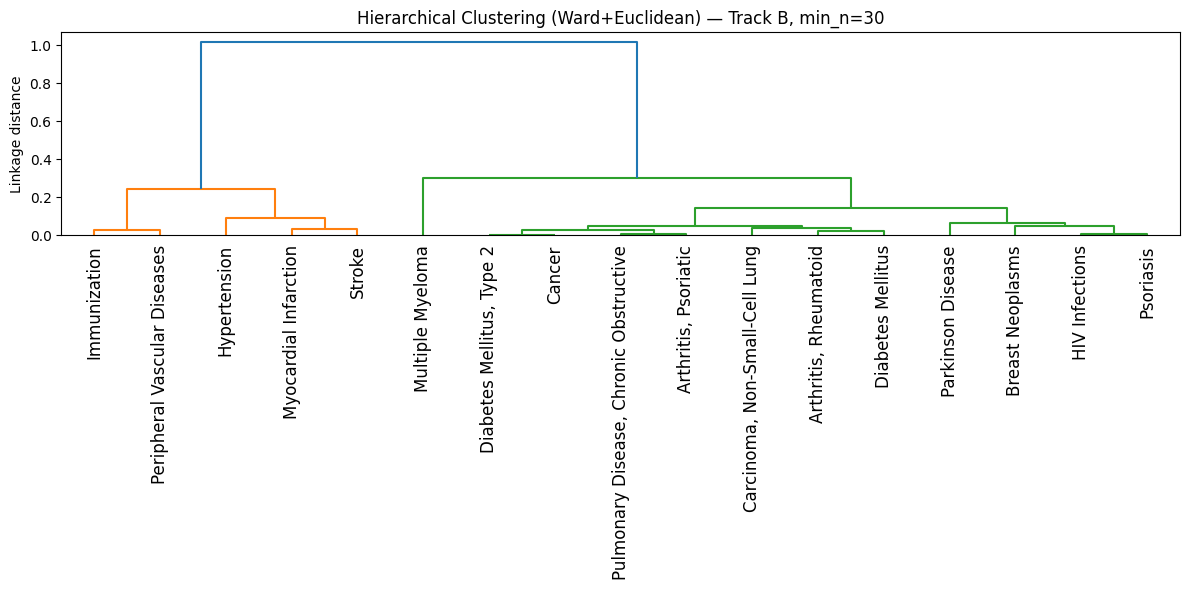

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Feature matrix: outcome proportions per therapeutic area
X = profiles_B[["p_authorised", "p_withdrawn", "p_refused"]].values
areas = profiles_B.index.tolist()

# Hierarchical clustering (Ward linkage)
Z = linkage(X, method="ward")  # Ward implies Euclidean distance

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=areas, leaf_rotation=90)
plt.title(f"Hierarchical Clustering (Ward+Euclidean) — Track B, min_n={MIN_N}")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dendrogram_ward_euclidean_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()

## 6. Refinement 1: Cross-Method Validation via K-Means
For K-Means we use:
- **Elbow method** (inertia/SSE)
- **Silhouette score**

Then we compare the K-Means grouping to the hierarchical recommendations.

In [8]:
# K-Means evaluation across a small range of k (Track B, min_n = MIN_N)
ks = list(range(2, 7))

rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X)
    rows.append({"k": k, "inertia": float(km.inertia_), "silhouette": float(silhouette_score(X, labels, metric="euclidean"))})

kmeans_eval = pd.DataFrame(rows)
display(kmeans_eval)

kmeans_eval.to_csv(os.path.join(OUT_DIR, f"kmeans_eval_min{MIN_N}.csv"), index=False)

,k,inertia,silhouette
0,2,0.096086,0.766014
1,3,0.051114,0.684695
2,4,0.021664,0.688703
3,5,0.010945,0.523180
4,6,0.006807,0.484569


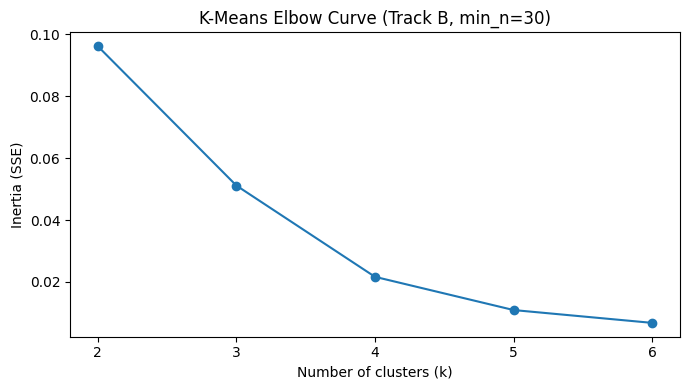

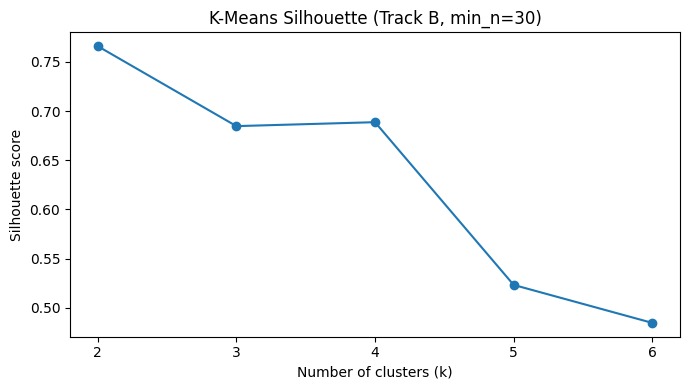

In [9]:
plt.figure(figsize=(7,4))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xticks(ks)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title(f"K-Means Elbow Curve (Track B, min_n={MIN_N})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"kmeans_elbow_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7,4))
plt.plot(kmeans_eval["k"], kmeans_eval["silhouette"], marker="o")
plt.xticks(ks)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title(f"K-Means Silhouette (Track B, min_n={MIN_N})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"kmeans_silhouette_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()

### Choose k for reporting (interpretability + validation)

In [10]:
# Selected k=2 to match the baseline M2 segmentation and maintain a clear "high-withdrawal vs high-authorization" interpretation.
K= 2

best_by_sil = kmeans_eval.sort_values("silhouette", ascending=False).head(1)
k2_row = kmeans_eval[kmeans_eval["k"] == K].iloc[0]

print(f"Silhouette at k={K}: {k2_row['silhouette']:.3f} | Inertia: {k2_row['inertia']:.4f}")
print(f"Best k by silhouette (exploratory): k={int(best_by_sil.iloc[0]['k'])} with silhouette={best_by_sil.iloc[0]['silhouette']:.3f}")

Silhouette at k=2: 0.766 | Inertia: 0.0961
Best k by silhouette (exploratory): k=2 with silhouette=0.766


For k=2, elbow pattern demonstrates large gains at low k and diminishing returns as k increases (see plots above).

### Compare cluster assignments: K-Means vs Hierarchical (baseline)
We compare cluster membership at the same k. This is not 'ground truth', but it is a useful consistency check.

In [11]:
# Hierarchical baseline labels (Ward + Euclidean) at the same k
labels_hier = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X)

# K-Means labels at the same k
labels_km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_SEED).fit_predict(X)

compare_df = profiles_B.copy()
compare_df = compare_df.reset_index().rename(columns={"therapeutic_area_clean": "therapeutic_area"})
compare_df["cluster_hier"] = labels_hier
compare_df["cluster_kmeans"] = labels_km

compare_df = compare_df[[
    "therapeutic_area", "cluster_hier", "cluster_kmeans",
    "p_authorised", "p_withdrawn", "p_refused", "n_total"
]].sort_values(["cluster_hier","p_withdrawn"], ascending=[True, False])

display(compare_df)

authorisation_status,therapeutic_area,cluster_hier,cluster_kmeans,p_authorised,p_withdrawn,p_refused,n_total
3,"Carcinoma, Non-Small-Cell Lung",0,1,0.770492,0.213115,0.016393,61
0,"Diabetes Mellitus, Type 2",0,1,0.792208,0.207792,0.000000,77
9,Cancer,0,1,0.794872,0.205128,0.000000,39
5,"Arthritis, Rheumatoid",0,1,0.784314,0.196078,0.019608,51
12,"Arthritis, Psoriatic",0,1,0.805556,0.194444,0.000000,36
11,"Pulmonary Disease, Chronic Obstructive",0,1,0.810811,0.189189,0.000000,37
8,Diabetes Mellitus,0,1,0.794872,0.179487,0.025641,39
1,HIV Infections,0,1,0.837838,0.162162,0.000000,74
2,Breast Neoplasms,0,1,0.809524,0.158730,0.031746,63
10,Psoriasis,0,1,0.842105,0.157895,0.000000,38


## 7. Refinement 2: Structural Interpretation via PCA
Dimensionality reduction via PCA helps interpret which outcome dimensions drive separation using:
- Explained variance
- PC loadings
- 2D plot colored by chosen cluster labels.

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

# Explained variance
evr = pca.explained_variance_ratio_
print("Explained variance ratio:", evr, "Cumulative:", evr.sum())

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=["p_authorised","p_withdrawn","p_refused"],
    columns=["PC1","PC2"]
)
display(loadings)

loadings.to_csv(os.path.join(OUT_DIR, f"pca_loadings_min{MIN_N}.csv"))

Explained variance ratio: [0.99502557 0.00497443] Cumulative: 1.0


,PC1,PC2
p_authorised,-0.696450,-0.426174
p_withdrawn,0.717302,-0.390057
p_refused,-0.020852,0.816230


In [13]:
# Interpretation (PCA)
pc1, pc2 = evr[0], evr[1]
print(f"PC1 explains {pc1*100:.2f}% of variance; PC2 explains {pc2*100:.2f}%.")

pc1_load = loadings["PC1"]
pc2_load = loadings["PC2"]

print("\nPC1 loadings (direction of separation):")
display(pc1_load.to_frame("PC1_loading"))

PC1 explains 99.50% of variance; PC2 explains 0.50%.

PC1 loadings (direction of separation):


,PC1_loading
p_authorised,-0.696450
p_withdrawn,0.717302
p_refused,-0.020852


Takeaway:
- PC1 is essentially a trade-off between withdrawal (positive) and authorization (negative).
- Refusal contributes very little to PC1, consistent with its low frequency in the data.

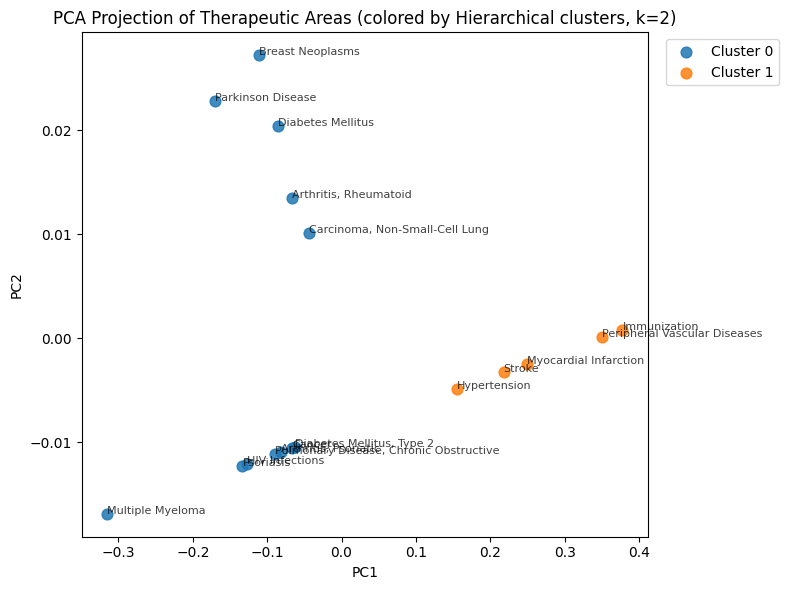

In [14]:
# Scatter in PCA space (color by hierarchical labels)
plt.figure(figsize=(8,6))
for cl in sorted(set(labels_hier)):
    idx = np.array(labels_hier) == cl
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=f"Cluster {cl}", s=60, alpha=0.85)

for i, name in enumerate(areas):
    plt.text(X_pca[i,0], X_pca[i,1], name, fontsize=8, alpha=0.75)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA Projection of Therapeutic Areas (colored by Hierarchical clusters, k={K})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"pca_scatter_hier_k{K}_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()

In the PCA map above, therapeutic areas separate primarily along PC1.
Areas with higher withdrawal rates appear on the positive PC1 side; high-authorization areas appear on the negative PC1 side.
This confirms the clustering is driven by a dominant one-dimensional risk gradient (withdrawal vs authorization).

## 8. Business-Facing Cluster Summary

In [15]:
summary = (compare_df
           .groupby("cluster_hier")
           .agg(
               n_areas=("therapeutic_area", "count"),
               total_medicines=("n_total", "sum"),
               mean_p_authorised=("p_authorised", "mean"),
               mean_p_withdrawn=("p_withdrawn", "mean"),
               mean_p_refused=("p_refused", "mean")
           )
           .sort_values("mean_p_withdrawn", ascending=False))

display(summary)
summary.to_csv(os.path.join(OUT_DIR, f"cluster_summary_hier_k{K}_min{MIN_N}.csv"))

,n_areas,total_medicines,mean_p_authorised,mean_p_withdrawn,mean_p_refused
cluster_hier,,,,,
1,5,203,0.556849,0.443151,0.000000
0,12,583,0.822177,0.167590,0.010233


Interpretation:
- Cluster 1 is the high-withdrawal regime (mean withdrawal = 44.3%).
- Cluster 0 is the high-authorization regime (mean authorization = 82.2%).
- The withdrawal gap between clusters is ~27.6 percentage points, which is economically meaningful for regulatory-risk planning.